# Exercise 1

Epoch 05, Loss: 0.013336, w: 1.0089, b: -0.9230
Epoch 10, Loss: 0.010022, w: 1.0012, b: -0.9752
Epoch 15, Loss: 0.009944, w: 1.0055, b: -0.9819
Epoch 20, Loss: 0.010039, w: 0.9996, b: -0.9817
Epoch 25, Loss: 0.009945, w: 1.0060, b: -0.9817

Final Results
True w: 1.0000, Learned w: 1.0060, Error: 0.005997
True b: -1.0000, Learned b: -0.9817, Error: 0.018326


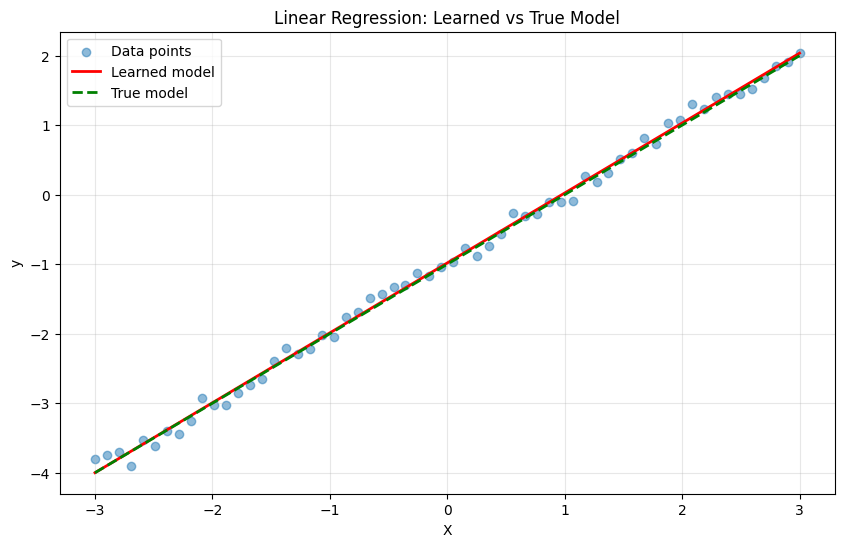

In [51]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

N = 60
X = torch.linspace(-3, 3, N).reshape(-1, 1)
true_w, true_b = 1.0, -1.0
epsilon = torch.normal(0, 0.1, (N, 1))
y = true_w * X + true_b + epsilon

model = nn.Sequential(nn.Linear(1, 1))

def mseloss(y_pred, y):
    return ((y_pred - y) ** 2).mean()

criterion = mseloss
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

batch_size = 10
num_epochs = 25

for epoch in range(num_epochs):
    indices = torch.randperm(N)
    for i in range(0, N, batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch, y_batch = X[batch_idx], y[batch_idx]

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            total_loss = criterion(model(X), y)
            w = model[0].weight.item()
            b = model[0].bias.item()
            print(f"Epoch {epoch+1:02d}, Loss: {total_loss:.6f}, w: {w:.4f}, b: {b:.4f}")

w = model[0].weight.item()
b = model[0].bias.item()

print("\n" + "="*50)
print("Final Results")
print("="*50)
print(f"True w: {true_w:.4f}, Learned w: {w:.4f}, Error: {abs(true_w - w):.6f}")
print(f"True b: {true_b:.4f}, Learned b: {b:.4f}, Error: {abs(true_b - b):.6f}")

plt.figure(figsize=(10, 6))
plt.scatter(X.numpy(), y.numpy(), alpha=0.5, label='Data points')
plt.plot(X.numpy(), model(X).detach().numpy(), 'r-', linewidth=2, label='Learned model')
plt.plot(X.numpy(), (true_w * X + true_b).numpy(), 'g--', linewidth=2, label='True model')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression: Learned vs True Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Exercise 2

In [55]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

1. Load MNIST Dataset

In [56]:

print("Loading MNIST dataset...")

# Transform to convert images to tensors and normalize to [0, 1]
trans = transforms.ToTensor()

# Download and load MNIST dataset
mnist_train = torchvision.datasets.MNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.MNIST(
    root="../data", train=False, transform=trans, download=True)

mnist_train, mnist_val = torch.utils.data.random_split(
    mnist_train, [30000, 30000], generator=torch.Generator().manual_seed(42))

print(f"Training set size: {len(mnist_train)}")
print(f"Validation set size: {len(mnist_val)}")
print(f"Test set size: {len(mnist_test)}")


Loading MNIST dataset...
Training set size: 30000
Validation set size: 30000
Test set size: 10000


2. Create Data Loaders with batch_size = 100

In [58]:
batch_size = 100

train_loader = torch.utils.data.DataLoader(
    mnist_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(
    mnist_val, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    mnist_test, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nBatch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Batch size: 100
Number of training batches: 300
Number of validation batches: 300
Number of test batches: 100


3. Build Softmax Regression Model

In [59]:
from torch import nn

# Flatten 28x28 images to 784-dimensional vectors
# Output layer: 10 classes (digits 0-9)
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 10)
)

# Initialize weights to 1 (as specified in the exercise)
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)
print("\nModel architecture:")
print(model)


Model architecture:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


4. Define Cross-Entropy Loss Function

In [60]:
loss_fn = nn.CrossEntropyLoss()

5. Mini-batch Stochastic Gradient Descent Optimizer (lr = 0.15)

In [61]:
lr = 0.15
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

print(f"\nOptimizer: SGD with learning rate = {lr}")


Optimizer: SGD with learning rate = 0.15


6. Training Function

In [62]:
def train_epoch(model, train_loader, loss_fn, optimizer):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    for X, y in train_loader:
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        total_correct += (y_pred.argmax(dim=1) == y).sum().item()
        total_samples += y.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100.0 * total_correct / total_samples
    return avg_loss, accuracy

def evaluate(model, data_loader, loss_fn):
    """Evaluate model on validation or test set."""
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for X, y in data_loader:
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            
            total_loss += loss.item()
            total_correct += (y_pred.argmax(dim=1) == y).sum().item()
            total_samples += y.size(0)
    
    avg_loss = total_loss / len(data_loader)
    accuracy = 100.0 * total_correct / total_samples
    return avg_loss, accuracy



7. Train the Model for 15 Epochs

In [63]:
num_epochs = 15

train_acc_all = []
val_acc_all = []
train_loss_all = []
val_loss_all = []

print(f"\n{'='*70}")
print(f"Training for {num_epochs} epochs...")
print(f"{'='*70}\n")

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer)
    train_acc_all.append(train_acc)
    train_loss_all.append(train_loss)
    
    # Validate
    val_loss, val_acc = evaluate(model, val_loader, loss_fn)
    val_acc_all.append(val_acc)
    val_loss_all.append(val_loss)
    
    print(f"Epoch {epoch + 1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\n{'='*70}")
print("Training completed!")
print(f"{'='*70}\n")



Training for 15 epochs...

Epoch  1/15 | Train Loss: 0.5785 | Train Acc: 85.89% | Val Loss: 0.4120 | Val Acc: 89.00%
Epoch  2/15 | Train Loss: 0.3703 | Train Acc: 89.78% | Val Loss: 0.3666 | Val Acc: 89.92%
Epoch  3/15 | Train Loss: 0.3364 | Train Acc: 90.58% | Val Loss: 0.3510 | Val Acc: 90.17%
Epoch  4/15 | Train Loss: 0.3191 | Train Acc: 91.01% | Val Loss: 0.3360 | Val Acc: 90.45%
Epoch  5/15 | Train Loss: 0.3070 | Train Acc: 91.46% | Val Loss: 0.3288 | Val Acc: 90.74%
Epoch  6/15 | Train Loss: 0.2986 | Train Acc: 91.59% | Val Loss: 0.3224 | Val Acc: 90.86%
Epoch  7/15 | Train Loss: 0.2921 | Train Acc: 91.89% | Val Loss: 0.3206 | Val Acc: 90.83%
Epoch  8/15 | Train Loss: 0.2867 | Train Acc: 91.97% | Val Loss: 0.3153 | Val Acc: 90.96%
Epoch  9/15 | Train Loss: 0.2828 | Train Acc: 92.11% | Val Loss: 0.3133 | Val Acc: 91.12%
Epoch 10/15 | Train Loss: 0.2787 | Train Acc: 92.31% | Val Loss: 0.3103 | Val Acc: 91.24%
Epoch 11/15 | Train Loss: 0.2755 | Train Acc: 92.37% | Val Loss: 0.3101 

8. Plot Accuracy for Training and Validation Sets

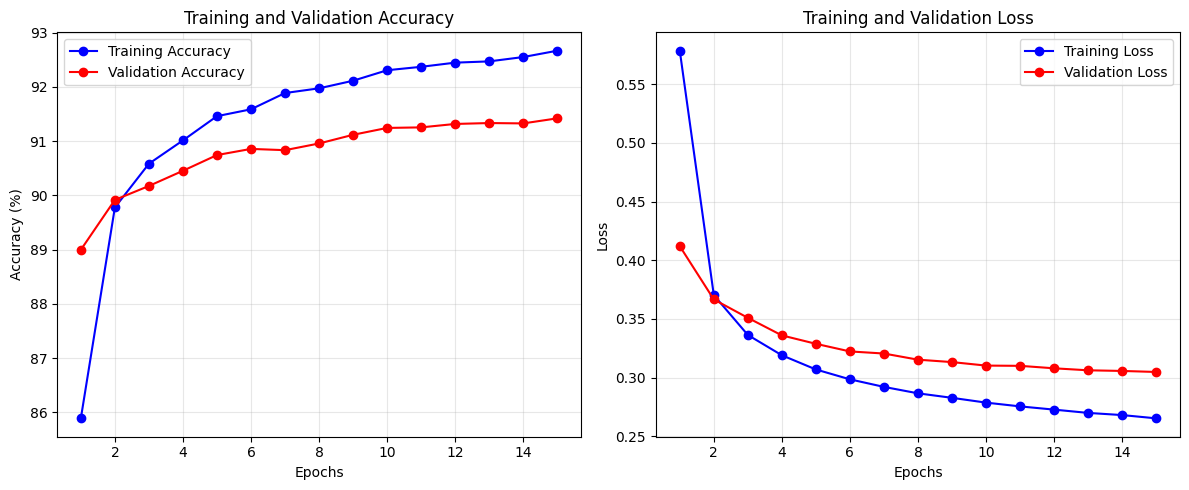

In [64]:
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, train_acc_all, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc_all, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_all, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss_all, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


9. Evaluate the Trained Model on Test Set

In [65]:
test_loss, test_acc = evaluate(model, test_loader, loss_fn)
print(f"\n{'='*70}")
print(f"Test Set Evaluation:")
print(f"{'='*70}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"{'='*70}\n")



Test Set Evaluation:
Test Loss: 0.2812
Test Accuracy: 92.15%



10. Classify 20 Sample Images

Visualizing 20 sample predictions from test set:



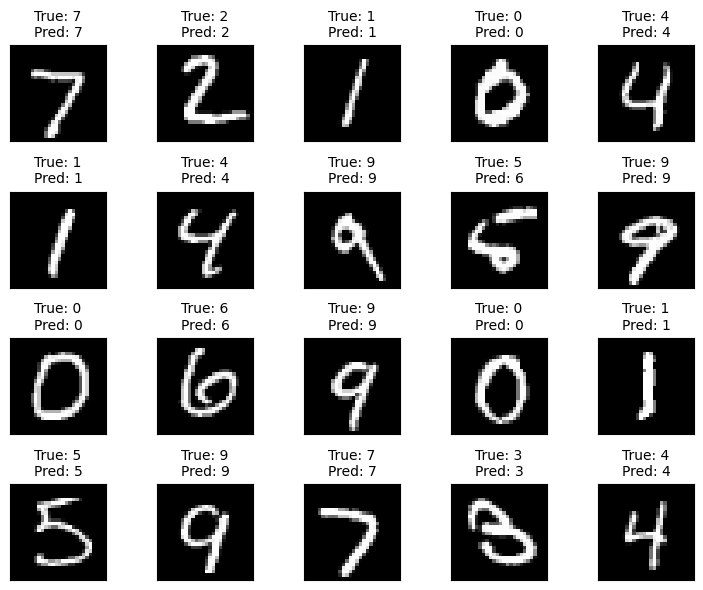


Accuracy on these 20 samples: 95.00%


In [66]:
def get_fashion_mnist_labels(labels):
    """Return text labels for digits."""
    return [str(int(i)) for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy().squeeze(), cmap='gray')
        else:
            ax.imshow(img, cmap='gray')
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i], fontsize=10)
    plt.tight_layout()
    return axes

# Get 20 test images
n = 20
X_test, y_test = next(iter(test_loader))
X_sample = X_test[:n]
y_sample = y_test[:n]

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_sample).argmax(dim=1)

# Create titles showing true label and prediction
trues = get_fashion_mnist_labels(y_sample)
preds = get_fashion_mnist_labels(predictions)
titles = [f'True: {true}\nPred: {pred}' for true, pred in zip(trues, preds)]

# Visualize
print("Visualizing 20 sample predictions from test set:\n")
show_images(X_sample.reshape(n, 28, 28), 4, 5, titles=titles)
plt.show()

# Calculate accuracy on these 20 samples
sample_accuracy = 100.0 * (predictions == y_sample).sum().item() / n
print(f"\nAccuracy on these {n} samples: {sample_accuracy:.2f}%")

# Exercise 3

In [42]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from torch import nn

torch.manual_seed(42)
np.random.seed(42)

1. Load MNIST Dataset


In [43]:
print("Loading MNIST dataset...")

trans = transforms.ToTensor()

mnist_train = torchvision.datasets.MNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.MNIST(
    root="../data", train=False, transform=trans, download=True)

# Split: 45000 training, 15000 validation (as per requirement)
mnist_train, mnist_val = torch.utils.data.random_split(
    mnist_train, [45000, 15000], generator=torch.Generator().manual_seed(42))

print(f"Training set size: {len(mnist_train)}")
print(f"Validation set size: {len(mnist_val)}")
print(f"Test set size: {len(mnist_test)}")

Loading MNIST dataset...
Training set size: 45000
Validation set size: 15000
Test set size: 10000


2. Create Data Loaders with batch_size = 512

In [44]:
batch_size = 512

train_loader = torch.utils.data.DataLoader(
    mnist_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(
    mnist_val, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    mnist_test, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nBatch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Batch size: 512
Number of training batches: 88
Number of validation batches: 30
Number of test batches: 20


3. Build MLP with Two Hidden Layers (256 units each)
    Hyperbolic Tangent activation + Dropout (40%)

In [45]:
dropout_prob = 0.4

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.Tanh(),
    nn.Dropout(dropout_prob),
    nn.Linear(256, 256),
    nn.Tanh(),
    nn.Dropout(dropout_prob),
    nn.Linear(256, 10)
)

4. Apply Xavier Initialization to Weights, Biases to Zero

In [46]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)
print("\nModel architecture:")
print(model)


Model architecture:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Tanh()
  (6): Dropout(p=0.4, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)


5. Define Cross-Entropy Loss Function

In [47]:
loss_fn = nn.CrossEntropyLoss()

6. Mini-batch Stochastic Gradient Descent Optimizer (lr = 0.15)

In [48]:
lr = 0.15
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

print(f"\nOptimizer: SGD with learning rate = {lr}")


Optimizer: SGD with learning rate = 0.15


7. Training and Evaluation Functions

In [49]:
def train_epoch(model, train_loader, loss_fn, optimizer):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    for X, y in train_loader:
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_correct += (y_pred.argmax(dim=1) == y).sum().item()
        total_samples += y.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100.0 * total_correct / total_samples
    return avg_loss, accuracy

def evaluate(model, data_loader, loss_fn):
    """Evaluate model on validation or test set."""
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for X, y in data_loader:
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            
            total_loss += loss.item()
            total_correct += (y_pred.argmax(dim=1) == y).sum().item()
            total_samples += y.size(0)
    
    avg_loss = total_loss / len(data_loader)
    accuracy = 100.0 * total_correct / total_samples
    return avg_loss, accuracy


8. Train the Model for 10 Epochs   

In [50]:
num_epochs = 10

train_acc_all = []
val_acc_all = []
train_loss_all = []
val_loss_all = []

print(f"\n{'='*70}")
print(f"Training MLP with Tanh activation and Dropout for {num_epochs} epochs...")
print(f"{'='*70}\n")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer)
    train_acc_all.append(train_acc)
    train_loss_all.append(train_loss)
    
    val_loss, val_acc = evaluate(model, val_loader, loss_fn)
    val_acc_all.append(val_acc)
    val_loss_all.append(val_loss)
    
    print(f"Epoch {epoch + 1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\n{'='*70}")
print("Training completed!")
print(f"{'='*70}\n")


Training MLP with Tanh activation and Dropout for 10 epochs...

Epoch  1/10 | Train Loss: 0.7174 | Train Acc: 78.52% | Val Loss: 0.3907 | Val Acc: 88.66%
Epoch  2/10 | Train Loss: 0.4165 | Train Acc: 87.61% | Val Loss: 0.3390 | Val Acc: 89.97%
Epoch  3/10 | Train Loss: 0.3723 | Train Acc: 89.05% | Val Loss: 0.3180 | Val Acc: 90.89%
Epoch  4/10 | Train Loss: 0.3534 | Train Acc: 89.59% | Val Loss: 0.3056 | Val Acc: 91.19%
Epoch  5/10 | Train Loss: 0.3376 | Train Acc: 89.83% | Val Loss: 0.2978 | Val Acc: 91.35%
Epoch  6/10 | Train Loss: 0.3231 | Train Acc: 90.50% | Val Loss: 0.2942 | Val Acc: 91.36%
Epoch  7/10 | Train Loss: 0.3202 | Train Acc: 90.52% | Val Loss: 0.2850 | Val Acc: 91.73%
Epoch  8/10 | Train Loss: 0.3129 | Train Acc: 90.82% | Val Loss: 0.2816 | Val Acc: 91.82%
Epoch  9/10 | Train Loss: 0.3054 | Train Acc: 90.96% | Val Loss: 0.2728 | Val Acc: 92.19%
Epoch 10/10 | Train Loss: 0.2967 | Train Acc: 91.36% | Val Loss: 0.2693 | Val Acc: 92.30%

Training completed!



9. Plot Training Progress

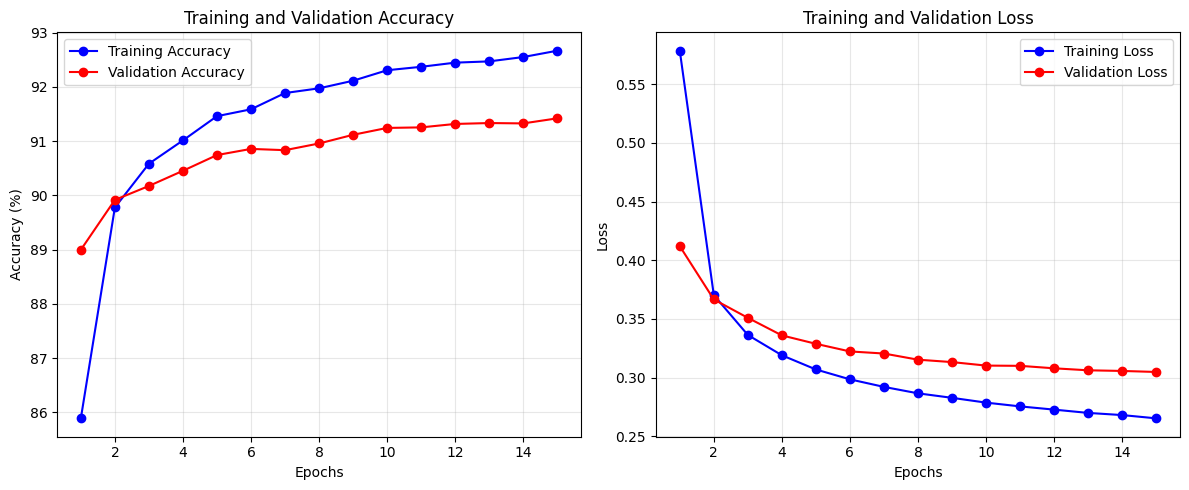

In [67]:
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, train_acc_all, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc_all, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_all, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss_all, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


10. Evaluate the Trained Model on Test Set

In [68]:
test_loss, test_acc = evaluate(model, test_loader, loss_fn)
print(f"\n{'='*70}")
print(f"Test Set Evaluation:")
print(f"{'='*70}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"{'='*70}\n")


Test Set Evaluation:
Test Loss: 0.2812
Test Accuracy: 92.15%

